# Analyse préliminaire 

Avant de faire le moindre entraînement, nécessité de regarder le rapport entre notre corpus et les baseline. Nécessité de construire un benchmark quali/quanti des modèles pour 1) orienter ce qui peut-être/doit être fait 2) évaluer les performances de l'entraînement.

Notamment, vérifier les choses suivantes :
- est-ce que les interventions d'un même débat présente une proximité sémantique forte *par rapport aux* interventions de débats différents ?
- est-ce que les interventions d'un même débat montrent une proximité sémantique équivalente selon s'il y a accord ou désaccord ?

In [31]:
import pandas as pd
import numpy as np
from ast import literal_eval
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
from os.path import join


## Quantative

### Comparaison de distance accord/désaccord intra/inter débats

On prend deux sources de données :
- notre dataset d'interventions à l'Assemblée lié à un scrutin commun
- le dataset X-Stance des paires question/commentaire généré depuis la plateforme Suisse Smartvote.

Méthode `compute_stats` 

- _Intra-débat_. On regroupe les interventions au sein d'un même débat. On calcule les distances cosinus de toutes les combinaisons d'interventions au sein de ce même débat selon si a) la combinaison est en accord (vote similaire) b) la combinaison est en désaccord (vote différent). On concatène toutes ces distances et on calcule 1) la moyenne 2) l'écart-type. Parce que notre dataset nous le permet, on regarde la différence de distance selon si le débat porte sur des amendements, des articles, des motions de rejet préalable ou des explications de vote.
- _Inter-débat_. On prend un échantillon d'interventions issus de débats différents. On applique la même méthode que pour les interventions intra-débats. On calcule moyenne et écart-type.

Méthode `compute_stats_xstance`

- _Intra-débat_. On regroupe les `comments` d'une même question. On calcule les distances cosinus de tous les comments liés par une même question selon si a) la combinaison est en accord (label similaire) b) la combinaison est en désaccord (label différent). On concatène toutes ces distances et on calcule 1) la moyenne 2) l'écart-type.
- _Intra-débat_. On prend un échantillon de comments issus de questions différentes. On applique la même méthode que pour les interventions intra-débats. On calcule moyenne et écart-type. 

Chaque comparaison est faite avec `Lajavaness/sentence-camembert-large` et `Qwen/Qwen3-Embedding-0.6B`.

In [3]:
def compute_stats(dir = "embed"):
    stats = {
        "inter": {
            "ALL": np.array([]),
            "AGREEMENT": np.array([]),
            "DESAGREEMENT": np.array([]),
        },
        "intra": {
            "amendments": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
            "articles": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
            "explanations": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
            "motions_rejet": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
        }
    }

    intervs_amds = pd.read_csv(f"./{dir}/intra_amendments.csv", converters={"embedding": literal_eval})
    intervs_other = pd.read_csv(f"./{dir}/intra_other.csv", converters={"embedding": literal_eval})

    intervs_articles = intervs_other[intervs_other["source"] == "article"]
    intervs_explanations = intervs_other[intervs_other["source"] == "explication_vote"]
    intervs_motions = intervs_other[intervs_other["source"] == "motion_rejet"]

    intra_dfs = (
        ("amendments",intervs_amds),
        ("articles", intervs_articles),
        ("explanations", intervs_explanations),
        ("motions_rejet", intervs_motions)
    )

    for grp_label, intervs in intra_dfs:
        for _, group in intervs.groupby("debate_id"):

            pour = group[group["vote"] == "POUR"]["embedding"].tolist()
            contre = group[group["vote"] == "CONTRE"]["embedding"].tolist()

            subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))

            for label, vec1, vec2 in subsets:

                if len(vec1) < 2 or len(vec2) < 2: 
                    continue

                cosine = cosine_distances(vec1, vec2)

                if label == "AGREEMENT":
                    rows, cols = np.triu_indices(cosine.shape[0], k=1)
                    cosine = cosine[rows, cols]


                stats["intra"][grp_label]["ALL"] = np.append(stats["intra"][grp_label]["ALL"], cosine.flatten())
                stats["intra"][grp_label][label] = np.append(stats["intra"][grp_label][label], cosine.flatten())

    intervs_inter = pd.read_csv(f"./{dir}/inter_sample.csv", converters={"embedding": literal_eval})
    pour = intervs_inter[intervs_inter["vote"] == "POUR"]["embedding"].tolist()
    contre = intervs_inter[intervs_inter["vote"] == "CONTRE"]["embedding"].tolist()

    subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))
    for label, vec1, vec2 in subsets:
        cosine = cosine_distances(vec1, vec2)

        if label == "AGREEMENT":
            rows, cols = np.triu_indices(cosine.shape[0], k=1)
            cosine = cosine[rows, cols]

        stats["inter"]["ALL"] = np.append(stats["inter"]["ALL"], cosine.flatten())
        stats["inter"][label] = np.append(stats["inter"][label], cosine.flatten())

    return stats

In [24]:
def compute_stats_xstance(dir="embed_camembert"):
    xstance = pd.read_csv(join(dir, "xstance_complete.csv"), converters={"embedding_comment": literal_eval})

    stats = {
        "intra": {
            "ALL": np.array([]),
            "AGREEMENT": np.array([]),
            "DESAGREEMENT": np.array([])
        },
        "inter": {
            "ALL": np.array([])
        }
    }

    for _, group in xstance.groupby("question_id"):
        favor = group[group["label"] == "FAVOR"]["embedding_comment"].tolist()
        against = group[group["label"] == "AGAINST"]["embedding_comment"].tolist()


        subsets = (("AGREEMENT", favor, favor), ("AGREEMENT", against, against), ("DESAGREEMENT", favor, against))

        for label, vec1, vec2 in subsets:

            if len(vec1) < 2 or len(vec2) < 2: 
                continue

            cosine = cosine_distances(vec1, vec2)

            if label == "AGREEMENT":
                rows, cols = np.triu_indices(cosine.shape[0], k=1)
                cosine = cosine[rows, cols]


            stats["intra"]["ALL"] = np.append(stats["intra"]["ALL"], cosine.flatten())
            stats["intra"][label] = np.append(stats["intra"][label], cosine.flatten())
    
    sample = xstance.drop_duplicates(subset="question_id")
    sample = sample["embedding_comment"].tolist()
    cosine = cosine_distances(sample, sample)
    rows, cols = np.triu_indices(cosine.shape[0], k=1)
    cosine = cosine[rows, cols]
    stats["inter"]["ALL"] = np.append(stats["inter"]["ALL"], cosine.flatten())

    return stats



#### Lajavaness/sentence-camembert-large

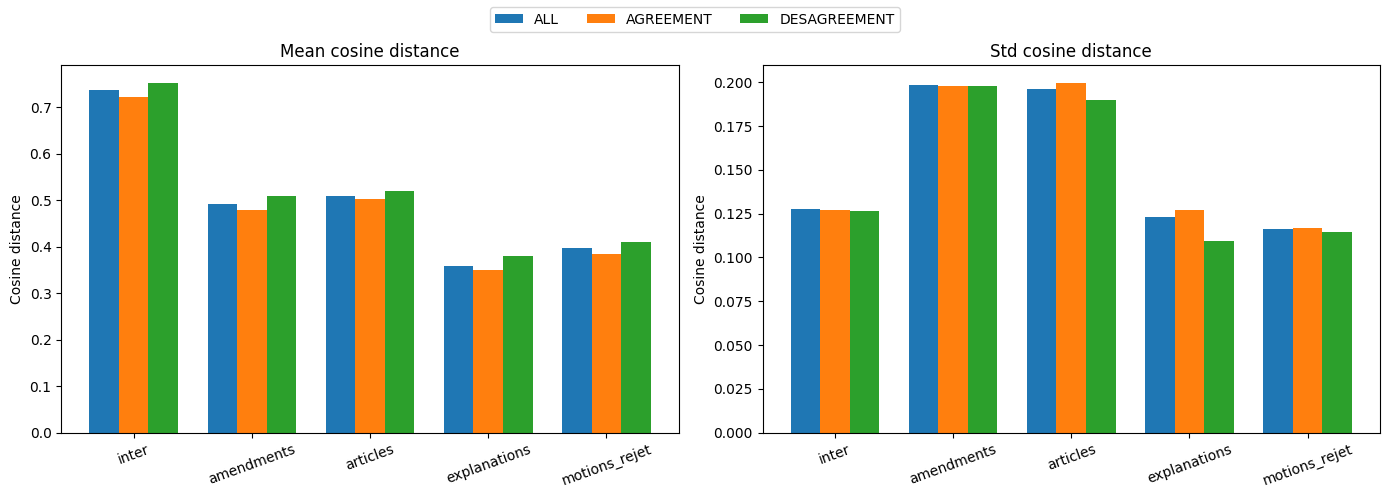

In [15]:
stats = compute_stats("embed_camembert")

groups = ["inter", "amendments", "articles", "explanations", "motions_rejet"]
labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]

def collect_metric(metric_fn):
    return {
        lbl: [metric_fn(stats["inter"][lbl])] + [metric_fn(stats["intra"][g][lbl]) for g in groups[1:]]
        for lbl in labels
    }

mean_values = collect_metric(np.mean)
std_values = collect_metric(np.std)

x = np.arange(len(groups))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
plots = [
    ("Mean cosine distance", mean_values, axes[0]),
    ("Std cosine distance", std_values, axes[1]),
]

for title, values, ax in plots:
    for j, lbl in enumerate(labels):
        ax.bar(x + (j - 1) * width, values[lbl], width=width, label=lbl)
    ax.set_title(title)
    ax.set_ylabel("Cosine distance")
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=20)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [32]:
x_stats = compute_stats_xstance("embed_camembert")

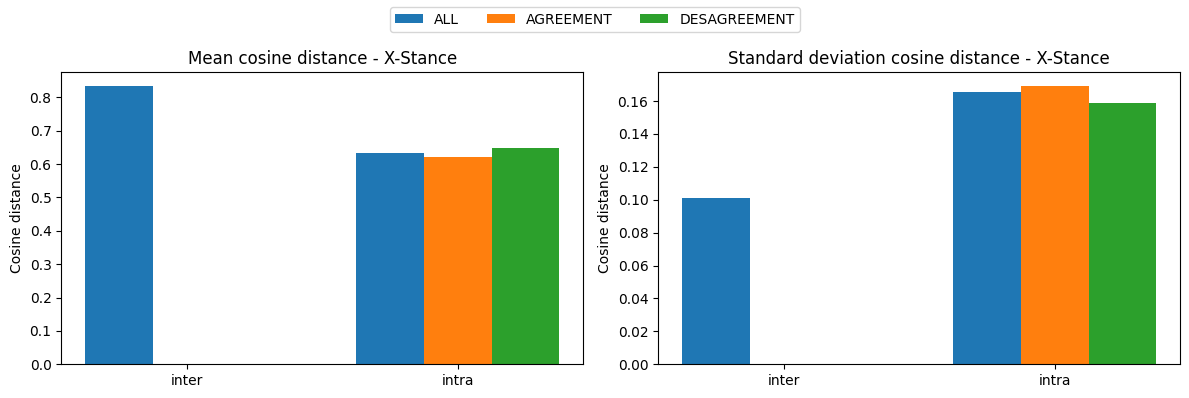

In [33]:

labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]
x_groups = ["inter", "intra"]

def collect_x_metric(metric_fn):
    values = {}
    for lbl in labels:
        inter_vals = x_stats["inter"].get(lbl, np.array([]))
        intra_vals = x_stats["intra"].get(lbl, np.array([]))
        values[lbl] = [
            metric_fn(inter_vals) if inter_vals.size else np.nan,
            metric_fn(intra_vals) if intra_vals.size else np.nan,
        ]
    return values

mean_values = collect_x_metric(np.mean)
std_values = collect_x_metric(np.std)

x = np.arange(len(x_groups))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
plots = [
    ("Mean cosine distance - X-Stance", mean_values, axes[0]),
    ("Standard deviation cosine distance - X-Stance", std_values, axes[1]),
]

for title, values, ax in plots:
    for j, lbl in enumerate(labels):
        ax.bar(x + (j - 1) * width, values[lbl], width=width, label=lbl)
    ax.set_title(title)
    ax.set_ylabel("Cosine distance")
    ax.set_xticks(x)
    ax.set_xticklabels(x_groups)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


#### Qwen/Qwen3-Embedding-0.6B

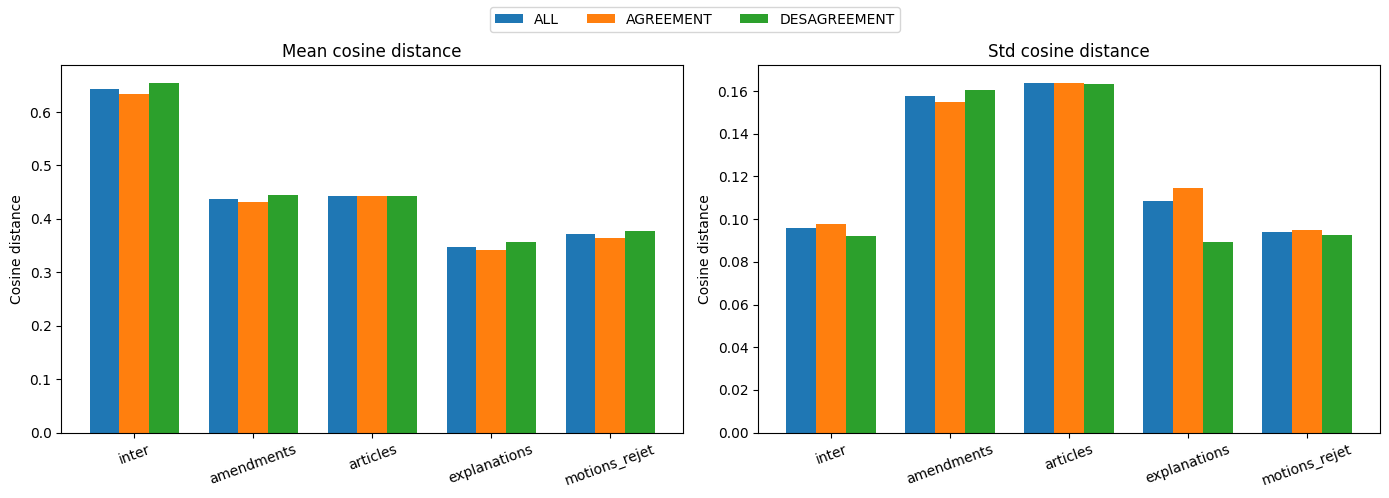

In [4]:
stats = compute_stats("embed_qwen3")

groups = ["inter", "amendments", "articles", "explanations", "motions_rejet"]
labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]

def collect_metric(metric_fn):
    return {
        lbl: [metric_fn(stats["inter"][lbl])] + [metric_fn(stats["intra"][g][lbl]) for g in groups[1:]]
        for lbl in labels
    }

mean_values = collect_metric(np.mean)
std_values = collect_metric(np.std)

x = np.arange(len(groups))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
plots = [
    ("Mean cosine distance", mean_values, axes[0]),
    ("Std cosine distance", std_values, axes[1]),
]

for title, values, ax in plots:
    for j, lbl in enumerate(labels):
        ax.bar(x + (j - 1) * width, values[lbl], width=width, label=lbl)
    ax.set_title(title)
    ax.set_ylabel("Cosine distance")
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=20)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [28]:
x_stats = compute_stats_xstance("embed_qwen3")

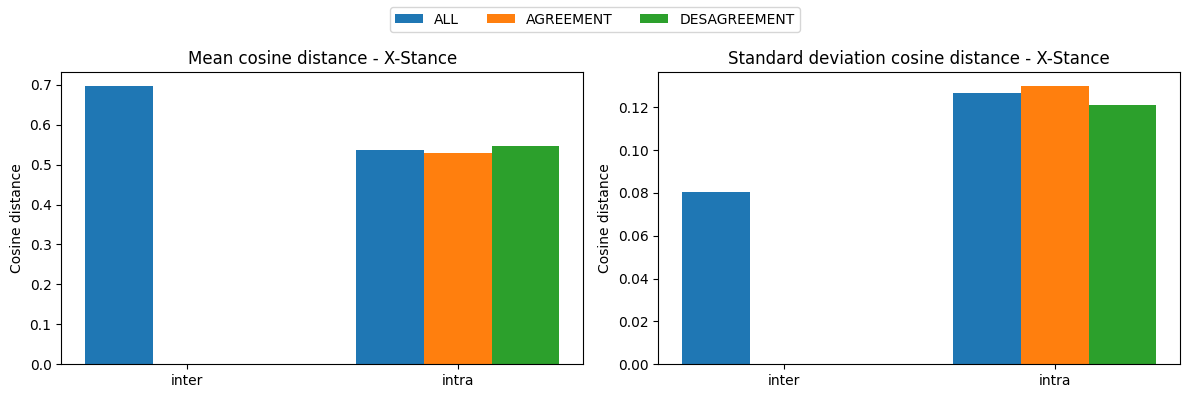

In [30]:

labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]
x_groups = ["inter", "intra"]

def collect_x_metric(metric_fn):
    values = {}
    for lbl in labels:
        inter_vals = x_stats["inter"].get(lbl, np.array([]))
        intra_vals = x_stats["intra"].get(lbl, np.array([]))
        values[lbl] = [
            metric_fn(inter_vals) if inter_vals.size else np.nan,
            metric_fn(intra_vals) if intra_vals.size else np.nan,
        ]
    return values

mean_values = collect_x_metric(np.mean)
std_values = collect_x_metric(np.std)

x = np.arange(len(x_groups))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
plots = [
    ("Mean cosine distance - X-Stance", mean_values, axes[0]),
    ("Standard deviation cosine distance - X-Stance", std_values, axes[1]),
]

for title, values, ax in plots:
    for j, lbl in enumerate(labels):
        ax.bar(x + (j - 1) * width, values[lbl], width=width, label=lbl)
    ax.set_title(title)
    ax.set_ylabel("Cosine distance")
    ax.set_xticks(x)
    ax.set_xticklabels(x_groups)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
